In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler
import pingouin as pg
import os
from tqdm import tqdm
import plotly.graph_objects as go
from scipy.stats import norm

import warnings
warnings.filterwarnings('ignore')
# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

from pycirclize import Circos
import itertools

# 数据命名与排序

In [2]:
df_session = pd.read_excel(
    r'E:\pycharm all files\眼动数据处理\相关性分析\数据\预处理后的数据\按session分开的_eeg&eye&scl&ppg+eeg_ratio+eeg_de.xlsx')
df_session.drop("AMP", axis=1, inplace=True)
df_session.columns = [
    '组别', '受试者', 'session',
    'SCL',
    'AOI', 'SGE', 'GTE',
    'HR', 'SDNN', 'RMSSD',
    'Cz_β_high', 'Fz_β_high', 'Pz_β_high',
    'Cz_β_low', 'Fz_β_low', 'Pz_β_low',
    'Cz_α/β_high', 'Cz_α/β_low', 'Cz_θ/β_high', 'Cz_θ/β_low',
    'Fz_α/β_high', 'Fz_α/β_low', 'Fz_θ/β_high', 'Fz_θ/β_low',
    'Pz_α/β_high', 'Pz_α/β_low', 'Pz_θ/β_high', 'Pz_θ/β_low',
    'DE_Cz_β_high', 'DE_Cz_β_low',
    'DE_Fz_β_high', 'DE_Fz_β_low',
    'DE_Pz_β_high', 'DE_Pz_β_low'
]

In [3]:
column_all_list = [
    '组别', '受试者', 'session',
    'SCL',
    'AOI', 'SGE', 'GTE',
    'HR', 'SDNN', 'RMSSD',
    'Fz_β_high', 'Cz_β_high', 'Pz_β_high',
    'Fz_α/β_high', 'Cz_α/β_high', 'Pz_α/β_high',
    'Fz_θ/β_high', 'Cz_θ/β_high', 'Pz_θ/β_high',
    'DE_Fz_β_high', 'DE_Cz_β_high', 'DE_Pz_β_high',
    'Fz_β_low', 'Cz_β_low', 'Pz_β_low',
    'Fz_α/β_low', 'Cz_α/β_low', 'Pz_α/β_low',
    'Fz_θ/β_low', 'Cz_θ/β_low', 'Pz_θ/β_low',
    'DE_Fz_β_low', 'DE_Cz_β_low', 'DE_Pz_β_low'
]

column_indicate_list = [
    'SCL',
    'AOI', 'SGE', 'GTE',
    'HR', 'SDNN', 'RMSSD',
    'Fz_β_high', 'Cz_β_high', 'Pz_β_high',
    'Fz_α/β_high', 'Cz_α/β_high', 'Pz_α/β_high',
    'Fz_θ/β_high', 'Cz_θ/β_high', 'Pz_θ/β_high',
    'DE_Fz_β_high', 'DE_Cz_β_high', 'DE_Pz_β_high',
    'Fz_β_low', 'Cz_β_low', 'Pz_β_low',
    'Fz_α/β_low', 'Cz_α/β_low', 'Pz_α/β_low',
    'Fz_θ/β_low', 'Cz_θ/β_low', 'Pz_θ/β_low',
    'DE_Fz_β_low', 'DE_Cz_β_low', 'DE_Pz_β_low'
]

df_session = df_session[column_all_list]

# df_session

In [4]:
latex_label_map = {
    # --------- 外周 & 行为 ----------
    "SCL": r"$\mathrm{SCL}$",
    "AOI": r"$\mathrm{AOI}$",
    "SGE": r"$\mathrm{SGE}$",
    "GTE": r"$\mathrm{GTE}$",

    # --------- 心率 ----------
    "HR": r"$\mathrm{HR}$",
    "SDNN": r"$\mathrm{SDNN}$",
    "RMSSD": r"$\mathrm{RMSSD}$",

    # --------- EEG 高频 ----------
    "Fz_β_high": r"$\mathrm{Fz}\,\beta_{\mathrm{high}}$",
    "Cz_β_high": r"$\mathrm{Cz}\,\beta_{\mathrm{high}}$",
    "Pz_β_high": r"$\mathrm{Pz}\,\beta_{\mathrm{high}}$",

    "Fz_α/β_high": r"$\mathrm{Fz}\,\alpha/\beta_{\mathrm{high}}$",
    "Cz_α/β_high": r"$\mathrm{Cz}\,\alpha/\beta_{\mathrm{high}}$",
    "Pz_α/β_high": r"$\mathrm{Pz}\,\alpha/\beta_{\mathrm{high}}$",

    "Fz_θ/β_high": r"$\mathrm{Fz}\,\theta/\beta_{\mathrm{high}}$",
    "Cz_θ/β_high": r"$\mathrm{Cz}\,\theta/\beta_{\mathrm{high}}$",
    "Pz_θ/β_high": r"$\mathrm{Pz}\,\theta/\beta_{\mathrm{high}}$",

    "DE_Fz_β_high": r"$\mathrm{DE} \mathrm{Fz}\,\beta_{\mathrm{high}}$",
    "DE_Cz_β_high": r"$\mathrm{DE} \mathrm{Cz}\,\beta_{\mathrm{high}}$",
    "DE_Pz_β_high": r"$\mathrm{DE} \mathrm{Pz}\,\beta_{\mathrm{high}}$",

    # --------- EEG 低频 ----------
    "Fz_β_low": r"$\mathrm{Fz}\,\beta_{\mathrm{low}}$",
    "Cz_β_low": r"$\mathrm{Cz}\,\beta_{\mathrm{low}}$",
    "Pz_β_low": r"$\mathrm{Pz}\,\beta_{\mathrm{low}}$",

    "Fz_α/β_low": r"$\mathrm{Fz}\,\alpha/\beta_{\mathrm{low}}$",
    "Cz_α/β_low": r"$\mathrm{Cz}\,\alpha/\beta_{\mathrm{low}}$",
    "Pz_α/β_low": r"$\mathrm{Pz}\,\alpha/\beta_{\mathrm{low}}$",

    "Fz_θ/β_low": r"$\mathrm{Fz}\,\theta/\beta_{\mathrm{low}}$",
    "Cz_θ/β_low": r"$\mathrm{Cz}\,\theta/\beta_{\mathrm{low}}$",
    "Pz_θ/β_low": r"$\mathrm{Pz}\,\theta/\beta_{\mathrm{low}}$",

    "DE_Fz_β_low": r"$\mathrm{DE} \mathrm{Fz}\,\beta_{\mathrm{low}}$",
    "DE_Cz_β_low": r"$\mathrm{DE} \mathrm{Cz}\,\beta_{\mathrm{low}}$",
    "DE_Pz_β_low": r"$\mathrm{DE} \mathrm{Pz}\,\beta_{\mathrm{low}}$",
}


# 生成排序变量

In [5]:
# =============================
# 统一 colormap：负-蓝，0-白，正-红
# =============================
white_center_cmap = LinearSegmentedColormap.from_list(
    "white_center",
    [(0.0, "blue"), (0.5, "white"), (1.0, "red")]
)

In [6]:
def make_rank_df(df, vars_to_rank, subject_col="受试者"):
    df_rank = df.copy()
    for v in vars_to_rank:
        df_rank[v] = df_rank.groupby(subject_col)[v].rank(method="average")
    return df_rank


rank_vars = column_indicate_list
df_rank = make_rank_df(df_session, rank_vars)

In [7]:
def rm_corr_matrix(df, vars_list, subject_col="受试者"):
    n = len(vars_list)
    R = pd.DataFrame(np.eye(n), index=vars_list, columns=vars_list)

    for i in range(n):
        for j in range(i + 1, n):
            try:
                r = pg.rm_corr(
                    data=df,
                    x=vars_list[i],
                    y=vars_list[j],
                    subject=subject_col
                )["r"].iloc[0]
            except:
                r = np.nan

            R.iloc[i, j] = r
            R.iloc[j, i] = r

    return R

In [8]:
groups = df_rank["组别"].unique()
rmcorr_matrices = {
    g: rm_corr_matrix(df_rank[df_rank["组别"] == g], rank_vars)
    for g in groups
}

# RM-corr 热力图（左下三角）

In [9]:
def plot_rmcorr_heatmap(R, title, save_path):
    mask = np.triu(np.ones_like(R, dtype=bool), k=1)

    latex_labels = [latex_label_map.get(c, c) for c in R.columns]

    plt.figure(figsize=(18, 15))
    ax = sns.heatmap(
        R,
        mask=mask,
        cmap=white_center_cmap,
        vmin=-1, vmax=1,
        square=True,
        annot=True, fmt=".2f",
        linewidths=.5,
        cbar_kws={"shrink": 0.6}
    )

    ax.set_xticklabels(latex_labels, rotation=45, ha="right", fontsize=11)
    ax.set_yticklabels(latex_labels, rotation=0, fontsize=11)

    plt.title(title, fontsize=18)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()


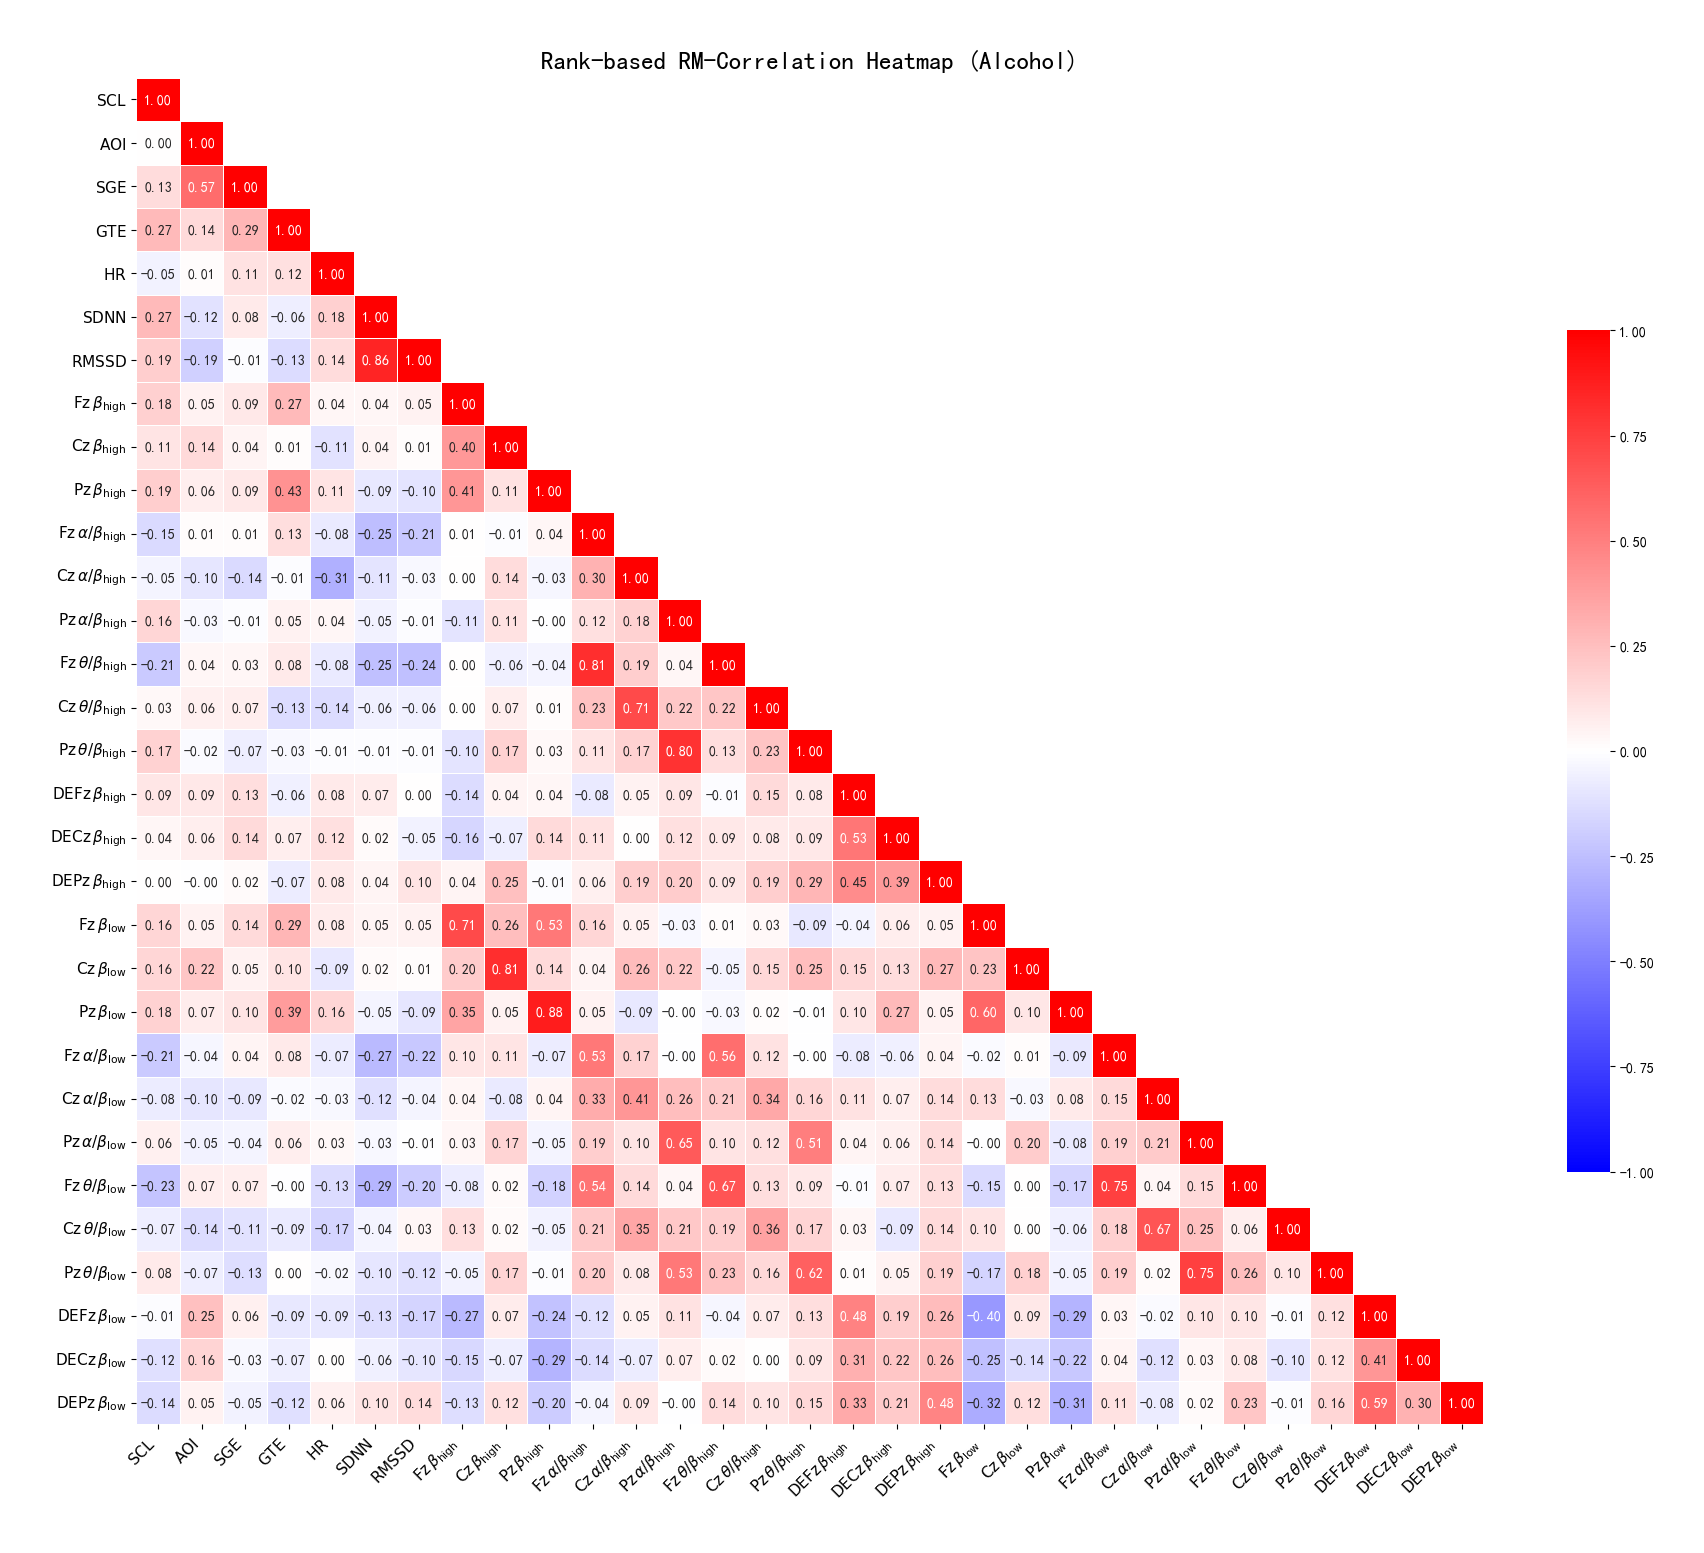

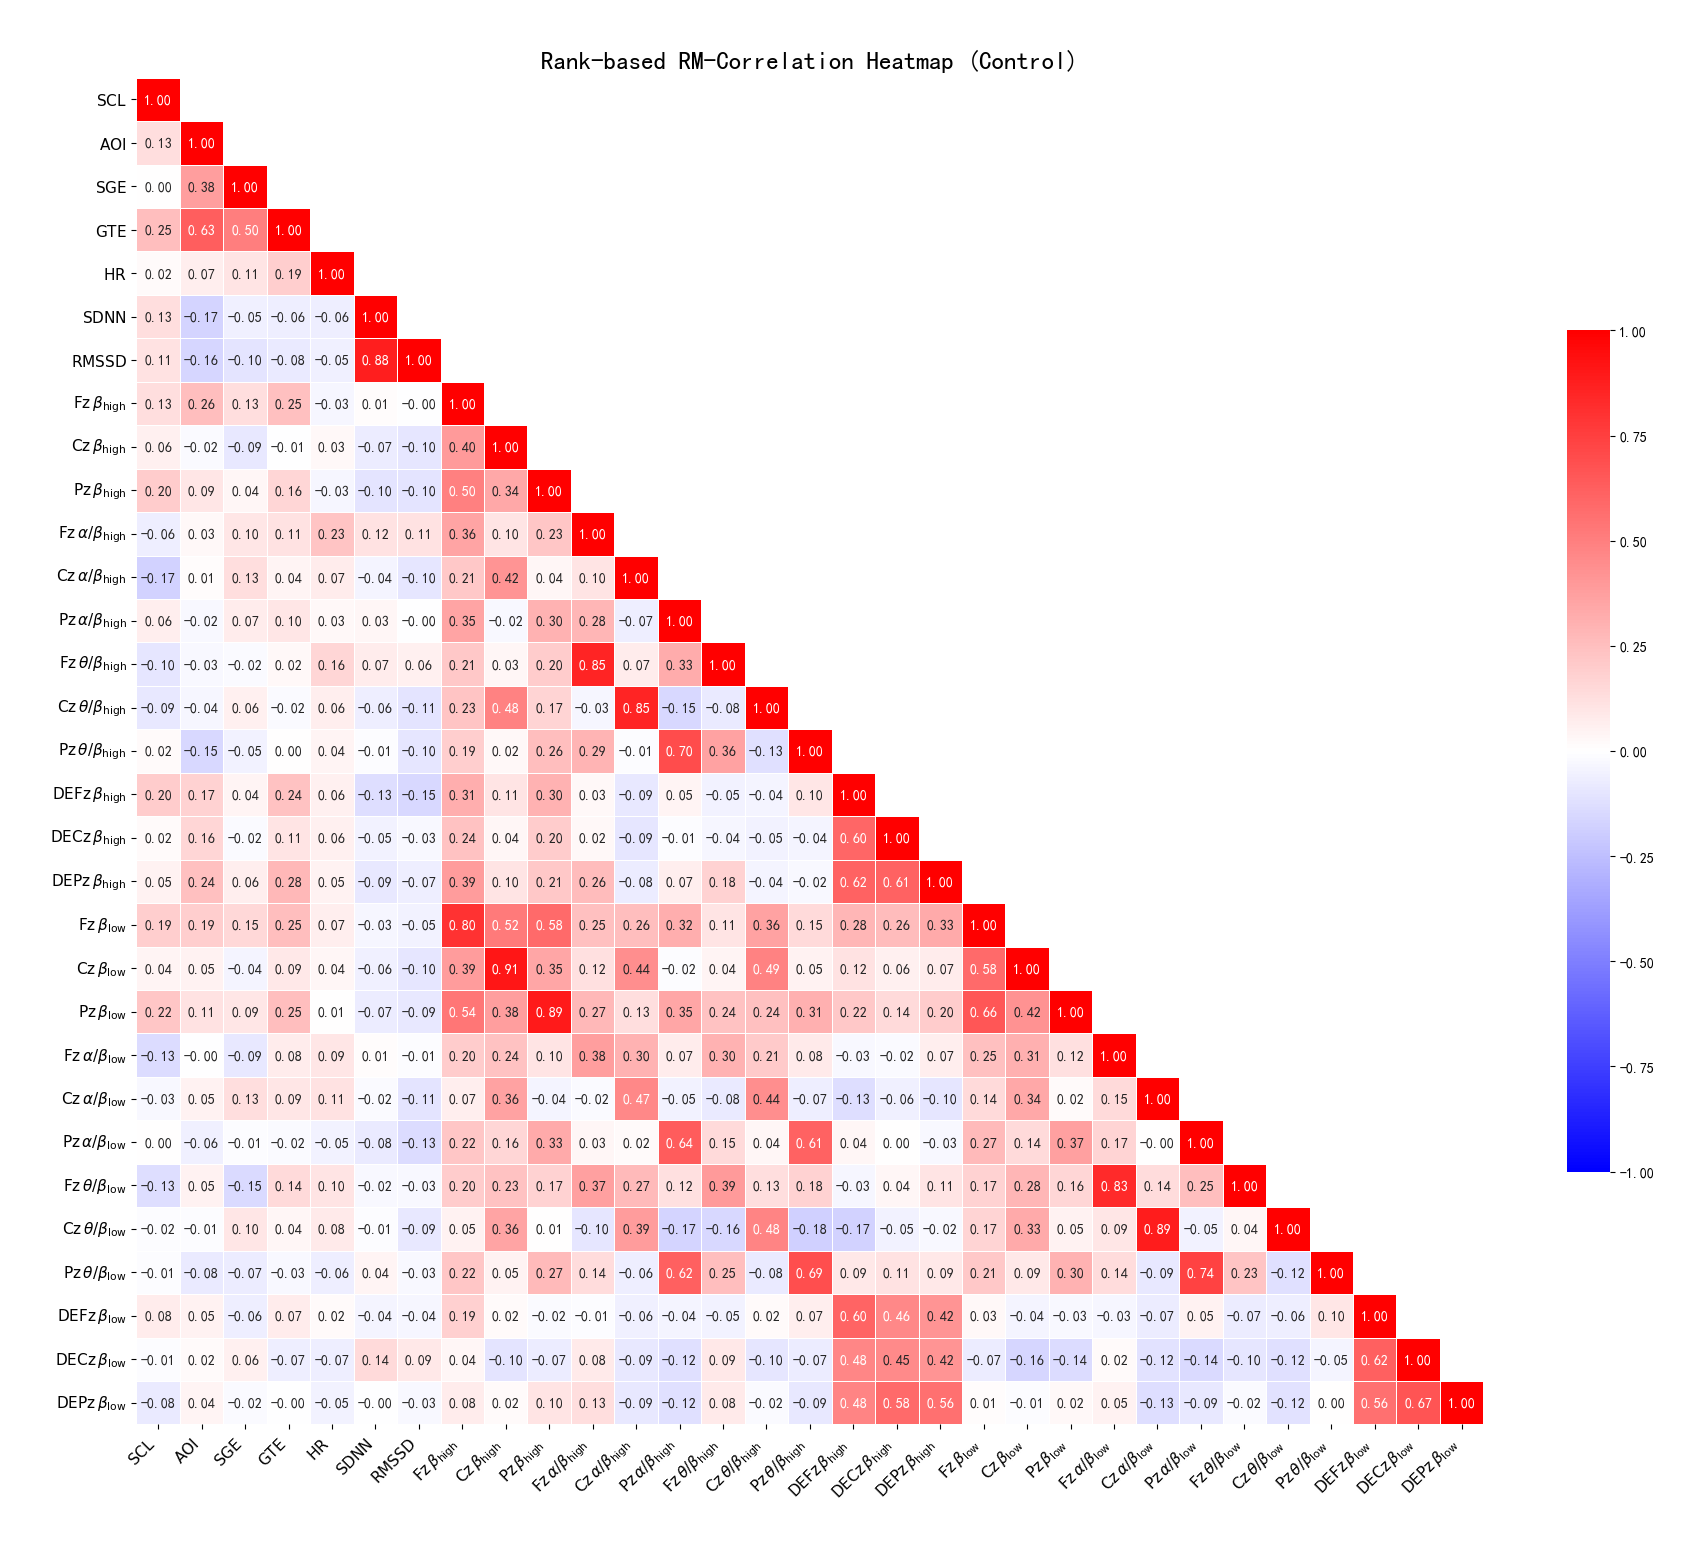

In [10]:
base_path = r"E:\pycharm all files\眼动数据处理\相关性分析\数据\预处理后的数据"

for g, R in rmcorr_matrices.items():
    plot_rmcorr_heatmap(
        R,
        title=f"Rank-based RM-Correlation Heatmap ({g})",
        save_path=f"{base_path}/rmcorr_heatmap_rank_{g}.png"
    )

# Fisher Z 热力图

In [11]:
def fisher_z_diff_matrix(R1, R2, n1, n2):
    Z = pd.DataFrame(np.zeros_like(R1), index=R1.index, columns=R1.columns)
    P = pd.DataFrame(np.ones_like(R1), index=R1.index, columns=R1.columns)

    for i in range(len(R1)):
        for j in range(len(R1)):
            if i == j:
                continue

            z1 = np.arctanh(R1.iloc[i, j])
            z2 = np.arctanh(R2.iloc[i, j])
            se = np.sqrt(1 / (n1 - 3) + 1 / (n2 - 3))

            z = (z1 - z2) / se
            p = 2 * (1 - norm.cdf(abs(z)))

            Z.iloc[i, j] = z
            P.iloc[i, j] = p

    return Z, P

In [12]:
df_alc = df_rank[df_rank["组别"] == "Alcohol"]
df_ctrl = df_rank[df_rank["组别"] == "Control"]

R_alc = rm_corr_matrix(df_alc, rank_vars)
R_ctrl = rm_corr_matrix(df_ctrl, rank_vars)

n_alc = df_alc["受试者"].nunique()
n_ctrl = df_ctrl["受试者"].nunique()

Z_diff, P_diff = fisher_z_diff_matrix(R_alc, R_ctrl, n_alc, n_ctrl)

In [13]:
def lower_triangle(df):
    df = df.copy()
    df.values[np.triu_indices_from(df, 1)] = np.nan
    return df

In [14]:
def plot_fisher_heatmap(Z, P, title, save_path):
    Z_plot = lower_triangle(Z).round(2)

    labels = Z_plot.astype(object)
    for i in range(len(Z)):
        for j in range(len(Z)):
            if pd.isna(Z_plot.iloc[i, j]):
                labels.iloc[i, j] = ""
            elif P.iloc[i, j] < 0.05 and i > j:
                labels.iloc[i, j] = rf"$\bf{{{Z_plot.iloc[i, j]}}}$"
            else:
                labels.iloc[i, j] = str(Z_plot.iloc[i, j])

    vmax = np.nanmax(np.abs(Z_plot.values))
    latex_labels = [latex_label_map.get(c, c) for c in Z.columns]

    plt.figure(figsize=(14, 12))
    ax = sns.heatmap(
        Z_plot,
        annot=labels, fmt="",
        cmap=white_center_cmap,
        center=0,
        vmin=-vmax, vmax=vmax,
        square=True,
        cbar=True
    )

    ax.set_xticklabels(latex_labels, rotation=45, ha="right", fontsize=11)
    ax.set_yticklabels(latex_labels, rotation=0, fontsize=11)

    plt.title(title, fontsize=18)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()


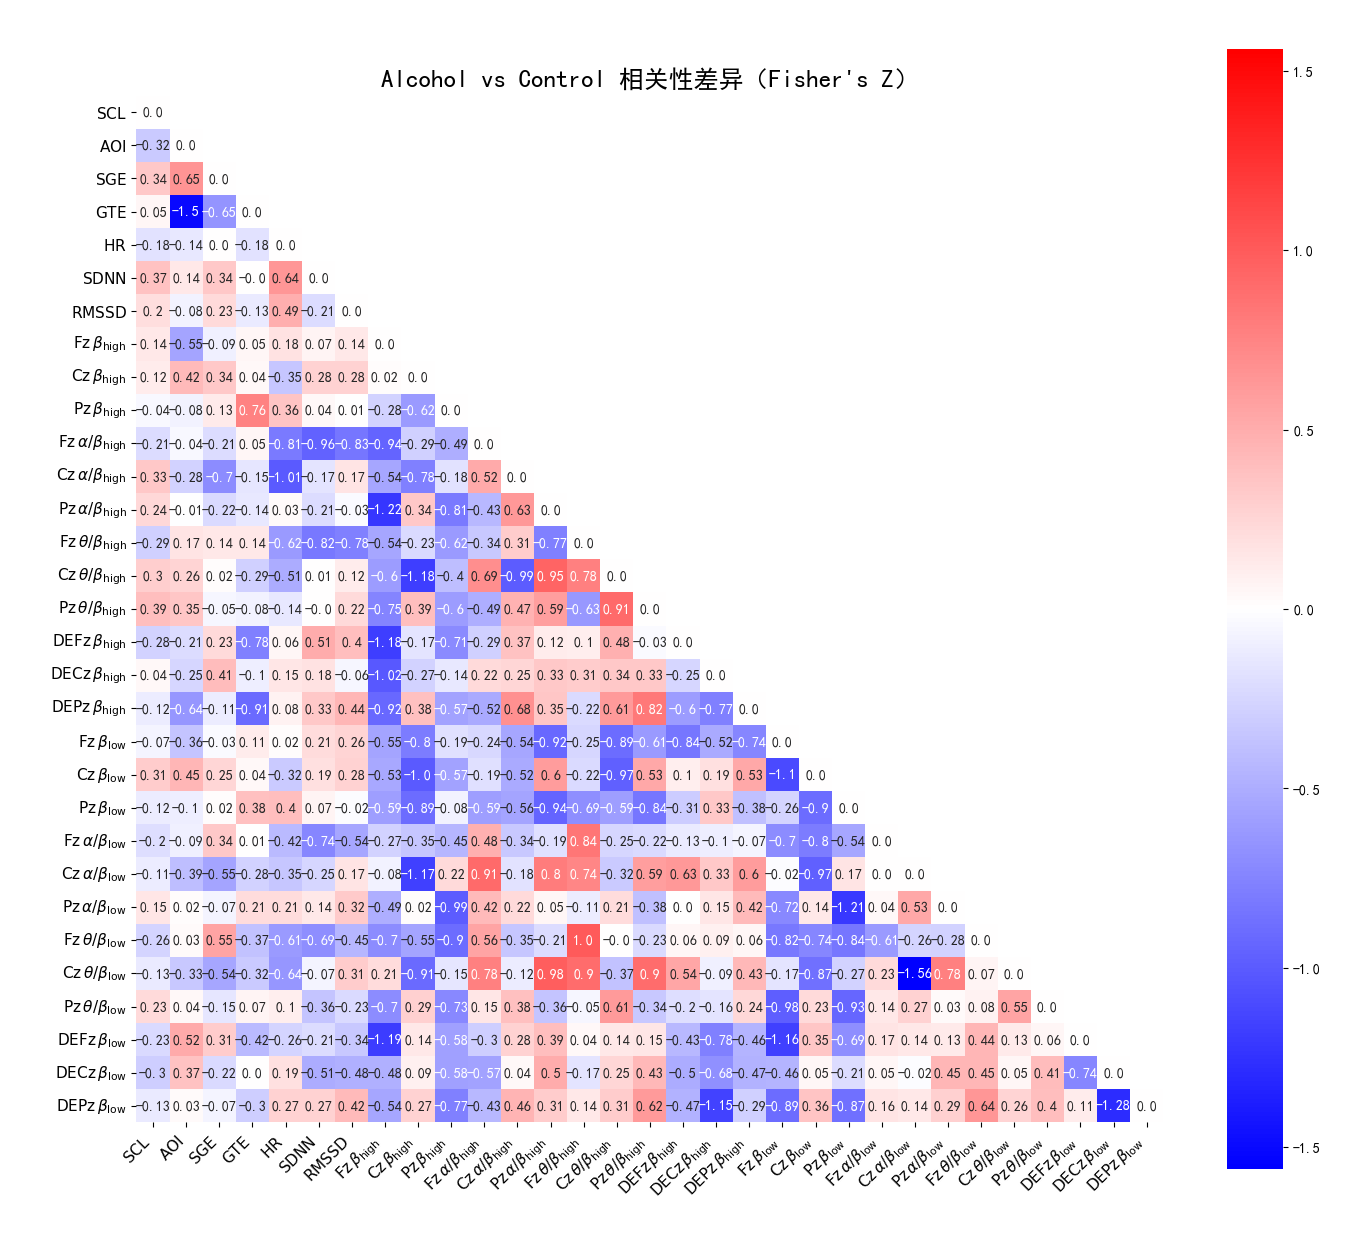

In [15]:
plot_fisher_heatmap(
    Z_diff,
    P_diff,
    title="Alcohol vs Control 相关性差异（Fisher's Z）",
    save_path=f"{base_path}/fisher_z_diff_heatmap.png"
)

# 环形相关性

In [16]:
rmcorr_matrices["Alcohol"]
rmcorr_matrices["Control"]

,SCL,AOI,SGE,GTE,HR,SDNN,RMSSD,Fz_β_high,Cz_β_high,Pz_β_high,...,Pz_β_low,Fz_α/β_low,Cz_α/β_low,Pz_α/β_low,Fz_θ/β_low,Cz_θ/β_low,Pz_θ/β_low,DE_Fz_β_low,DE_Cz_β_low,DE_Pz_β_low
SCL,1.000000e+00,0.125000,5.551115e-17,0.250000,0.021217,0.130653,0.112786,0.127232,0.060268,0.200893,...,0.223214,-0.133929,-3.125000e-02,6.245005e-17,-0.129464,-0.015625,-0.013393,0.077486,-0.008994,-0.084607
AOI,1.250000e-01,1.000000,3.750000e-01,0.625000,0.068118,-0.170854,-0.157454,0.256696,-0.020089,0.093750,...,0.111607,-0.004464,5.357143e-02,-5.803571e-02,0.053571,-0.011161,-0.084821,0.048288,0.020237,0.039483
SGE,5.551115e-17,0.375000,1.000000e+00,0.500000,0.108319,-0.054718,-0.103853,0.127232,-0.091518,0.035714,...,0.093750,-0.089286,1.250000e-01,-1.339286e-02,-0.147321,0.100446,-0.071429,-0.064010,0.060710,-0.021434
GTE,2.500000e-01,0.625000,5.000000e-01,1.000000,0.188721,-0.063652,-0.081519,0.247768,-0.006696,0.156250,...,0.254464,0.075893,9.375000e-02,-1.785714e-02,0.142857,0.037946,-0.026786,0.072994,-0.069704,-0.003384
HR,2.121720e-02,0.068118,1.083194e-01,0.188721,1.000000,-0.063687,-0.054749,-0.034618,0.026801,-0.033501,...,0.005583,0.093802,1.094361e-01,-5.248465e-02,0.103853,0.078169,-0.063652,0.015731,-0.068618,-0.049664
SDNN,1.306533e-01,-0.170854,-5.471804e-02,-0.063652,-0.063687,1.000000,0.877095,0.007817,-0.071468,-0.104969,...,-0.074819,0.013400,-2.233390e-02,-8.151872e-02,-0.023451,-0.013400,0.041318,-0.044945,0.142860,-0.001129
RMSSD,1.127862e-01,-0.157454,-1.038526e-01,-0.081519,-0.054749,0.877095,1.000000,-0.003350,-0.100503,-0.104969,...,-0.088219,-0.011167,-1.072027e-01,-1.328867e-01,-0.027917,-0.087102,-0.027917,-0.037079,0.087741,-0.027089
Fz_β_high,1.272321e-01,0.256696,1.272321e-01,0.247768,-0.034618,0.007817,-0.003350,1.000000,0.397321,0.497768,...,0.535714,0.200893,6.919643e-02,2.187500e-01,0.196429,0.046875,0.218750,0.186416,0.035976,0.077839
Cz_β_high,6.026786e-02,-0.020089,-9.151786e-02,-0.006696,0.026801,-0.071468,-0.100503,0.397321,1.000000,0.339286,...,0.375000,0.241071,3.616071e-01,1.584821e-01,0.234375,0.357143,0.051339,0.019091,-0.103432,0.016921
Pz_β_high,2.008929e-01,0.093750,3.571429e-02,0.156250,-0.033501,-0.104969,-0.104969,0.497768,0.339286,1.000000,...,0.890625,0.102679,-4.241071e-02,3.281250e-01,0.174107,0.006696,0.267857,-0.016845,-0.074201,0.102657


In [17]:
cmap1 = {
    # GSR
    "SCL": "#4CAF50",

    # Eye
    "AOI": "#FFA500",
    "SGE": "#FFA500",
    "GTE": "#FFA500",

    # PPG
    "HR": "#1E90FF",
    "SDNN": "#1E90FF",
    "RMSSD": "#1E90FF",

    # -------- EEG：High Beta（深红） --------
    "Cz_β_high": "#D7301F",
    "Fz_β_high": "#D7301F",
    "Pz_β_high": "#D7301F",
    "DE_Cz_β_high": "#D7301F",
    "DE_Fz_β_high": "#D7301F",
    "DE_Pz_β_high": "#D7301F",
    "Cz_α/β_high": "#D7301F",
    "Cz_θ/β_high": "#D7301F",
    "Fz_α/β_high": "#D7301F",
    "Fz_θ/β_high": "#D7301F",
    "Pz_α/β_high": "#D7301F",
    "Pz_θ/β_high": "#D7301F",

    # -------- EEG：Low Beta（紫色） --------
    "Cz_β_low": "purple",
    "Fz_β_low": "purple",
    "Pz_β_low": "purple",
    "DE_Cz_β_low": "purple",
    "DE_Fz_β_low": "purple",
    "DE_Pz_β_low": "purple",
    "Cz_α/β_low": "purple",
    "Cz_θ/β_low": "purple",
    "Fz_α/β_low": "purple",
    "Fz_θ/β_low": "purple",
    "Pz_α/β_low": "purple",
    "Pz_θ/β_low": "purple",
}
node_order = list(cmap1.keys())

In [18]:
import numpy as np
from pycirclize import Circos


def plot_chord_pos_neg(
    corr_df,
    cmap,
    thresholds,
    prefix,
    space=5,
    label_size=15
):
    """
    对相关矩阵：
      - 使用上三角
      - 不同 threshold
      - 正 / 负相关分开画 chord diagram
      - 节点顺序严格遵循 cmap 的 key 顺序
    """

    # 只保留上三角（不含对角线）
    corr_ut = corr_df.where(
        np.triu(np.ones(corr_df.shape), k=1).astype(bool)
    )

    # cmap 中定义的“全局节点顺序”
    cmap_nodes = list(cmap.keys())

    for th in thresholds:

        # ==================================================
        # ================= 正相关 =========================
        # ==================================================
        pos_weights = corr_ut.where(corr_ut >= th, 0).fillna(0)

        if (pos_weights.values > 0).any():

            # 只要“参与过至少一条边”的节点就保留（OR！）
            nodes = [
                n for n in pos_weights.columns
                if (pos_weights.loc[n].sum() > 0) or (pos_weights[n].sum() > 0)
            ]

            # 按 cmap 的顺序重新排列
            nodes = [n for n in cmap_nodes if n in nodes]
            mat = pos_weights.loc[nodes, nodes]

            # 🔑 删除完全孤立的节点（只用 OR，不用 AND）
            valid = (mat.sum(axis=1) > 0) | (mat.sum(axis=0) > 0)
            mat = mat.loc[valid, valid]

            # 🔴 终极防炸（真的画不了才跳）
            if mat.shape[0] < 2 or mat.values.sum() == 0:
                print(f"[{prefix}] th={th} 正相关无有效连接，跳过")
            else:
                circos = Circos.chord_diagram(
                    mat,
                    space=space,
                    cmap={k: cmap[k] for k in mat.index},
                    label_kws=dict(orientation="vertical", size=label_size),
                    link_kws=dict(lw=0.6, ec="none")
                )
                circos.savefig(f"{prefix}_POS_th{th}.png", dpi=300)
                print("Saved:", f"{prefix}_POS_th{th}.png")

        else:
            print(f"[{prefix}] th={th} 无正相关")


        # ==================================================
        # ================= 负相关 =========================
        # ==================================================
        neg_weights = corr_ut.where(corr_ut <= -th, 0).fillna(0).abs()

        if (neg_weights.values > 0).any():

            nodes = [
                n for n in neg_weights.columns
                if (neg_weights.loc[n].sum() > 0) or (neg_weights[n].sum() > 0)
            ]

            nodes = [n for n in cmap_nodes if n in nodes]
            mat = neg_weights.loc[nodes, nodes]

            valid = (mat.sum(axis=1) > 0) | (mat.sum(axis=0) > 0)
            mat = mat.loc[valid, valid]

            # 🔴 终极防炸
            if mat.shape[0] < 2 or mat.values.sum() == 0:
                print(f"[{prefix}] th={th} 负相关无有效连接，跳过")
            else:
                circos = Circos.chord_diagram(
                    mat,
                    space=space,
                    cmap={k: cmap[k] for k in mat.index},
                    label_kws=dict(orientation="vertical", size=label_size),
                    link_kws=dict(lw=0.6, ec="none")
                )
                circos.savefig(f"{prefix}_NEG_th{th}.png", dpi=300)
                print("Saved:", f"{prefix}_NEG_th{th}.png")

        else:
            print(f"[{prefix}] th={th} 无负相关")


In [19]:
thresholds = [0.2, 0.4, 0.6, 0.8]

plot_chord_pos_neg(
    corr_df=rmcorr_matrices["Alcohol"],
    cmap=cmap1,
    thresholds=thresholds,
    prefix="Alcohol_chord",
    label_size=15
)


Saved: Alcohol_chord_POS_th0.2.png
Saved: Alcohol_chord_NEG_th0.2.png
Saved: Alcohol_chord_POS_th0.4.png
Saved: Alcohol_chord_NEG_th0.4.png
Saved: Alcohol_chord_POS_th0.6.png
[Alcohol_chord] th=0.6 无负相关
Saved: Alcohol_chord_POS_th0.8.png
[Alcohol_chord] th=0.8 无负相关


In [20]:
plot_chord_pos_neg(
    corr_df=rmcorr_matrices["Control"],
    cmap=cmap1,
    thresholds=thresholds,
    prefix="Control_chord",
    label_size=15
)

Saved: Control_chord_POS_th0.2.png
[Control_chord] th=0.2 无负相关
Saved: Control_chord_POS_th0.4.png
[Control_chord] th=0.4 无负相关
Saved: Control_chord_POS_th0.6.png
[Control_chord] th=0.6 无负相关
Saved: Control_chord_POS_th0.8.png
[Control_chord] th=0.8 无负相关


# fisher'z

In [21]:
def plot_fisherZ_chord(
    Z_diff,
    P_diff,
    cmap,
    p_thresholds,
    prefix,
    space=5,
    label_size=15
):
    """
    Fisher’s Z 差异弦图：
      - 上三角
      - 不同 p 阈值
      - 一张图同时展示正 / 负 Z
      - 颜色区分方向（RdBu_r）
      - 节点顺序严格遵循 cmap 的 key 顺序
    """

    # ---------------- 上三角 ----------------
    Z_ut = Z_diff.where(
        np.triu(np.ones(Z_diff.shape), k=1).astype(bool)
    )
    P_ut = P_diff.where(
        np.triu(np.ones(P_diff.shape), k=1).astype(bool)
    )

    # cmap 中定义的全局顺序
    cmap_nodes = list(cmap.keys())

    for p_th in p_thresholds:

        # ---------------- 显著 Fisher Z（保留正负） ----------------
        Z_sig = Z_ut.where(P_ut < p_th, 0).fillna(0)

        if not (Z_sig.values != 0).any():
            print(f"[{prefix}] p<{p_th} 无显著 Fisher Z")
            continue

        # ---------------- 参与过任意一条边的节点（OR） ----------------
        nodes = [
            n for n in Z_sig.columns
            if (Z_sig.loc[n].abs().sum() > 0) or (Z_sig[n].abs().sum() > 0)
        ]

        # 严格按 cmap 顺序
        nodes = [n for n in cmap_nodes if n in nodes]
        mat = Z_sig.loc[nodes, nodes]

        # ---------------- 再次清理孤立节点（OR） ----------------
        valid = (mat.abs().sum(axis=1) > 0) | (mat.abs().sum(axis=0) > 0)
        mat = mat.loc[valid, valid]

        # ---------------- 防炸 ----------------
        if mat.shape[0] < 2 or mat.abs().values.sum() == 0:
            print(f"[{prefix}] p<{p_th} 无可绘制连接，跳过")
            continue

        # ---------------- 绘图 ----------------
        circos = Circos.chord_diagram(
            mat.abs(),                 # 边粗细 = |Z|
            space=space,
            cmap="RdBu_r",             # 颜色由 Z 正负决定
            label_kws=dict(
                orientation="vertical",
                size=label_size
            ),
            link_kws=dict(lw=0.6, ec="none")
        )

        circos.savefig(f"FisherZ_p{p_th}_{prefix}.png", dpi=300)
        print("Saved:", f"FisherZ_p{p_th}_{prefix}.png")


In [47]:
plot_fisherZ_chord(
    Z_diff,
    P_diff,
    cmap=cmap1,
    p_thresholds=[0.5, 0.4, 0.3, 0.2, 0.1],
    prefix="Alcohol_vs_Control"
)


Saved: FisherZ_p0.5_Alcohol_vs_Control.png
Saved: FisherZ_p0.4_Alcohol_vs_Control.png
Saved: FisherZ_p0.3_Alcohol_vs_Control.png
Saved: FisherZ_p0.2_Alcohol_vs_Control.png
[Alcohol_vs_Control] p<0.1 无显著 Fisher Z


# 正相关连接计数

In [23]:
# -------- EEG beta 分组 --------
beta_low_vars = [
    c for c in column_indicate_list
    if ("β_low" in c)
]

beta_high_vars = [
    c for c in column_indicate_list
    if ("β_high" in c)
]

# -------- 其他模态 --------
eye_vars = ["AOI", "SGE", "GTE"]
ppg_vars = ["HR", "SDNN", "RMSSD"]
scl_vars = ["SCL"]

In [24]:
def count_positive_connections(corr_df, threshold):
    """
    返回一个 dict，记录各类正连接数量
    """

    # 只取上三角
    corr_ut = corr_df.where(
        np.triu(np.ones(corr_df.shape), k=1).astype(bool)
    )

    # 只保留正相关
    corr_pos = corr_ut.where(corr_ut >= threshold, 0)

    counts = {}

    # ---------- EEG 内部 ----------
    counts["within_beta_low"] = sum(
        corr_pos.loc[i, j] > 0
        for i, j in itertools.combinations(beta_low_vars, 2)
        if i in corr_pos.index and j in corr_pos.columns
    )

    counts["within_beta_high"] = sum(
        corr_pos.loc[i, j] > 0
        for i, j in itertools.combinations(beta_high_vars, 2)
        if i in corr_pos.index and j in corr_pos.columns
    )

    counts["between_beta_low_high"] = sum(
        corr_pos.loc[i, j] > 0
        for i in beta_low_vars
        for j in beta_high_vars
        if i in corr_pos.index and j in corr_pos.columns
    )

    # ---------- EEG ↔ Eye ----------
    counts["Eye_low_beta"] = sum(
        corr_pos.loc[e, b] > 0
        for e in eye_vars
        for b in beta_low_vars
        if e in corr_pos.index and b in corr_pos.columns
    )

    counts["Eye_high_beta"] = sum(
        corr_pos.loc[e, b] > 0
        for e in eye_vars
        for b in beta_high_vars
        if e in corr_pos.index and b in corr_pos.columns
    )

    # ---------- EEG ↔ PPG ----------
    counts["PPG_low_beta"] = sum(
        corr_pos.loc[p, b] > 0
        for p in ppg_vars
        for b in beta_low_vars
        if p in corr_pos.index and b in corr_pos.columns
    )

    counts["PPG_high_beta"] = sum(
        corr_pos.loc[p, b] > 0
        for p in ppg_vars
        for b in beta_high_vars
        if p in corr_pos.index and b in corr_pos.columns
    )

    # ---------- EEG ↔ SCL ----------
    counts["SCL_low_beta"] = sum(
        corr_pos.loc["SCL", b] > 0
        for b in beta_low_vars
        if "SCL" in corr_pos.index and b in corr_pos.columns
    )

    counts["SCL_high_beta"] = sum(
        corr_pos.loc["SCL", b] > 0
        for b in beta_high_vars
        if "SCL" in corr_pos.index and b in corr_pos.columns
    )

    return counts

In [25]:
thresholds = [0.2, 0.4, 0.6, 0.8]

rows = []

for group in ["Alcohol", "Control"]:
    corr_df = rmcorr_matrices[group]

    for th in thresholds:
        counts = count_positive_connections(corr_df, th)
        counts["Group"] = group
        counts["Threshold"] = th
        rows.append(counts)

summary_df = pd.DataFrame(rows)


In [26]:
summary_df = summary_df[
    [
        "Group", "Threshold",
        "within_beta_low",
        "within_beta_high",
        "between_beta_low_high",
        "Eye_low_beta", "Eye_high_beta",
        "PPG_low_beta", "PPG_high_beta",
        "SCL_low_beta", "SCL_high_beta"
    ]
]

summary_df

,Group,Threshold,within_beta_low,within_beta_high,between_beta_low_high,Eye_low_beta,Eye_high_beta,PPG_low_beta,PPG_high_beta,SCL_low_beta,SCL_high_beta
0,Alcohol,0.2,12,16,0,4,2,0,0,0,0
1,Alcohol,0.4,6,7,0,0,1,0,0,0,0
2,Alcohol,0.6,4,3,0,0,0,0,0,0,0
3,Alcohol,0.8,0,1,0,0,0,0,0,0,0
4,Control,0.2,20,29,0,2,5,0,1,1,2
5,Control,0.4,9,9,0,0,0,0,0,0,0
6,Control,0.6,6,6,0,0,0,0,0,0,0
7,Control,0.8,2,2,0,0,0,0,0,0,0


# 负相关连接计数

In [27]:
def count_negative_connections(corr_df, threshold):
    """
    统计负相关（r <= -threshold）连接数量
    """

    # 上三角
    corr_ut = corr_df.where(
        np.triu(np.ones(corr_df.shape), k=1).astype(bool)
    )

    # 只保留负相关
    corr_neg = corr_ut.where(corr_ut <= -threshold, 0)

    out = {}

    # ===== EEG 内部 =====
    out["within_beta_low"] = sum(
        corr_neg.loc[i, j] < 0
        for i, j in itertools.combinations(beta_low_vars, 2)
        if i in corr_neg.index and j in corr_neg.columns
    )

    out["within_beta_high"] = sum(
        corr_neg.loc[i, j] < 0
        for i, j in itertools.combinations(beta_high_vars, 2)
        if i in corr_neg.index and j in corr_neg.columns
    )

    out["between_beta_low_high"] = sum(
        corr_neg.loc[i, j] < 0
        for i in beta_low_vars
        for j in beta_high_vars
        if i in corr_neg.index and j in corr_neg.columns
    )

    # ===== EEG ↔ Eye =====
    out["Eye_low_beta"] = sum(
        corr_neg.loc[e, b] < 0
        for e in eye_vars
        for b in beta_low_vars
        if e in corr_neg.index and b in corr_neg.columns
    )

    out["Eye_high_beta"] = sum(
        corr_neg.loc[e, b] < 0
        for e in eye_vars
        for b in beta_high_vars
        if e in corr_neg.index and b in corr_neg.columns
    )

    # ===== EEG ↔ PPG =====
    out["PPG_low_beta"] = sum(
        corr_neg.loc[p, b] < 0
        for p in ppg_vars
        for b in beta_low_vars
        if p in corr_neg.index and b in corr_neg.columns
    )

    out["PPG_high_beta"] = sum(
        corr_neg.loc[p, b] < 0
        for p in ppg_vars
        for b in beta_high_vars
        if p in corr_neg.index and b in corr_neg.columns
    )

    # ===== EEG ↔ SCL =====
    out["SCL_low_beta"] = sum(
        corr_neg.loc["SCL", b] < 0
        for b in beta_low_vars
        if "SCL" in corr_neg.index and b in corr_neg.columns
    )

    out["SCL_high_beta"] = sum(
        corr_neg.loc["SCL", b] < 0
        for b in beta_high_vars
        if "SCL" in corr_neg.index and b in corr_neg.columns
    )

    return out


In [28]:
thresholds = [0.2, 0.4, 0.6, 0.8]

rows = []

for group in ["Alcohol", "Control"]:
    corr_df = rmcorr_matrices[group]

    for th in thresholds:
        res = count_negative_connections(corr_df, th)
        res["Group"] = group
        res["Threshold"] = th
        rows.append(res)

negative_conn_df = pd.DataFrame(rows)


In [29]:
negative_conn_df = negative_conn_df[
    [
        "Group", "Threshold",

        "within_beta_low",
        "within_beta_high",
        "between_beta_low_high",

        "Eye_low_beta",
        "Eye_high_beta",

        "PPG_low_beta",
        "PPG_high_beta",

        "SCL_low_beta",
        "SCL_high_beta",
    ]
]

negative_conn_df


,Group,Threshold,within_beta_low,within_beta_high,between_beta_low_high,Eye_low_beta,Eye_high_beta,PPG_low_beta,PPG_high_beta,SCL_low_beta,SCL_high_beta
0,Alcohol,0.2,6,0,0,0,0,4,5,2,1
1,Alcohol,0.4,1,0,0,0,0,0,0,0,0
2,Alcohol,0.6,0,0,0,0,0,0,0,0,0
3,Alcohol,0.8,0,0,0,0,0,0,0,0,0
4,Control,0.2,0,0,0,0,0,0,0,0,0
5,Control,0.4,0,0,0,0,0,0,0,0,0
6,Control,0.6,0,0,0,0,0,0,0,0,0
7,Control,0.8,0,0,0,0,0,0,0,0,0


# fisher‘z计数

In [44]:
def count_negative_fisher_connections(Z_diff, P_diff, p_th=0.05):
    """
    统计 Fisher's Z 负差异（Control > Alcohol）
    与 Fisher Z chord 图保持一致（仅 p 阈值）
    """

    # 上三角
    Z_ut = Z_diff.where(
        np.triu(np.ones(Z_diff.shape), k=1).astype(bool)
    )
    P_ut = P_diff.where(
        np.triu(np.ones(P_diff.shape), k=1).astype(bool)
    )

    # 只保留：显著 + 负向 Z
    Z_neg = Z_ut.where((Z_ut < 0) & (P_ut < p_th), 0)

    out = {}

    # ===== EEG 内部 =====
    out["within_beta_low"] = sum(
        Z_neg.loc[i, j] < 0
        for i, j in itertools.combinations(beta_low_vars, 2)
        if i in Z_neg.index and j in Z_neg.columns
    )

    out["within_beta_high"] = sum(
        Z_neg.loc[i, j] < 0
        for i, j in itertools.combinations(beta_high_vars, 2)
        if i in Z_neg.index and j in Z_neg.columns
    )

    out["between_beta_low_high"] = sum(
        Z_neg.loc[i, j] < 0
        for i in beta_low_vars
        for j in beta_high_vars
        if i in Z_neg.index and j in Z_neg.columns
    )

    # ===== EEG ↔ Eye =====
    out["Eye_low_beta"] = sum(
        Z_neg.loc[e, b] < 0
        for e in eye_vars
        for b in beta_low_vars
        if e in Z_neg.index and b in Z_neg.columns
    )

    out["Eye_high_beta"] = sum(
        Z_neg.loc[e, b] < 0
        for e in eye_vars
        for b in beta_high_vars
        if e in Z_neg.index and b in Z_neg.columns
    )

    # ===== EEG ↔ PPG =====
    out["PPG_low_beta"] = sum(
        Z_neg.loc[p, b] < 0
        for p in ppg_vars
        for b in beta_low_vars
        if p in Z_neg.index and b in Z_neg.columns
    )

    out["PPG_high_beta"] = sum(
        Z_neg.loc[p, b] < 0
        for p in ppg_vars
        for b in beta_high_vars
        if p in Z_neg.index and b in Z_neg.columns
    )

    # ===== EEG ↔ SCL =====
    out["SCL_low_beta"] = sum(
        Z_neg.loc["SCL", b] < 0
        for b in beta_low_vars
        if "SCL" in Z_neg.index and b in Z_neg.columns
    )

    out["SCL_high_beta"] = sum(
        Z_neg.loc["SCL", b] < 0
        for b in beta_high_vars
        if "SCL" in Z_neg.index and b in Z_neg.columns
    )

    return out

In [45]:
p_thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]

rows = []

for p_th in p_thresholds:
    res = count_negative_fisher_connections(
        Z_diff,
        P_diff,
        p_th=p_th
    )
    res["p_threshold"] = p_th
    rows.append(res)

In [46]:
fisher_neg_count_df = pd.DataFrame(rows)

fisher_neg_count_df = fisher_neg_count_df[
    [
        "p_threshold",

        "within_beta_low",
        "within_beta_high",
        "between_beta_low_high",

        "Eye_low_beta",
        "Eye_high_beta",

        "PPG_low_beta",
        "PPG_high_beta",

        "SCL_low_beta",
        "SCL_high_beta",
    ]
]

fisher_neg_count_df

,p_threshold,within_beta_low,within_beta_high,between_beta_low_high,Eye_low_beta,Eye_high_beta,PPG_low_beta,PPG_high_beta,SCL_low_beta,SCL_high_beta
0,0.5,20,13,0,0,3,2,6,0,0
1,0.4,12,7,0,0,1,0,2,0,0
2,0.3,5,3,0,0,0,0,0,0,0
3,0.2,1,0,0,0,0,0,0,0,0
4,0.1,0,0,0,0,0,0,0,0,0


# 跨模态连接网络（cross-modal connectivity network）

In [33]:
eeg_vars = [
    'Fz_β_high',
    'Cz_β_high', 'Pz_β_high', 'Fz_α/β_high', 'Cz_α/β_high', 'Pz_α/β_high',
    'Fz_θ/β_high', 'Cz_θ/β_high', 'Pz_θ/β_high', 'DE_Fz_β_high',
    'DE_Cz_β_high', 'DE_Pz_β_high', 'Fz_β_low', 'Cz_β_low', 'Pz_β_low',
    'Fz_α/β_low', 'Cz_α/β_low', 'Pz_α/β_low', 'Fz_θ/β_low', 'Cz_θ/β_low',
    'Pz_θ/β_low', 'DE_Fz_β_low', 'DE_Cz_β_low', 'DE_Pz_β_low'
]

In [34]:
other_vars = ['SCL', 'AOI', 'SGE', 'GTE', 'HR', 'SDNN', 'RMSSD']

## Alcohol组-跨模态网络绘制

In [35]:
inner_alcohol_weights = alcohol_weights.copy()

for i in inner_alcohol_weights.index:
    for j in inner_alcohol_weights.columns:

        # 情况 1：脑电 ↔ 脑电 → 置 0
        if (i in eeg_vars) and (j in eeg_vars):
            inner_alcohol_weights.loc[i, j] = 0

        # 情况 2：非脑电 ↔ 非脑电 → 置 0
        elif (i in other_vars) and (j in other_vars):
            inner_alcohol_weights.loc[i, j] = 0

        # 情况 3：脑电 ↔ 其他模态 → 保留
        else:
            pass
# 只保留上三角（避免重复画弦）
inner_alcohol_weights = inner_alcohol_weights.where(
    np.triu(np.ones(inner_alcohol_weights.shape), k=1).astype(bool)
)

# 删除“整行或整列都是 0”的指标（非常关键）
inner_alcohol_weights = inner_alcohol_weights.fillna(0)

inner_alcohol_weights = inner_alcohol_weights.loc[
    (inner_alcohol_weights.sum(axis=1) > 0),
    (inner_alcohol_weights.sum(axis=0) > 0)
]
inner_alcohol_weights

NameError: name 'alcohol_weights' is not defined

In [ ]:
# 绘图
circos = Circos.chord_diagram(
    inner_alcohol_weights,
    space=5,
    cmap=cmap1,
    label_kws=dict(orientation="vertical", size=15),
    link_kws=dict(lw=0.6, ec="none")
)

circos.savefig("Alcohol_EEG_cross_modal_chord.png", dpi=300)


## Control组-跨模态网络绘制

In [ ]:
inner_control_weights = control_weights.copy()

for i in inner_control_weights.index:
    for j in inner_control_weights.columns:

        # 情况 1：脑电 ↔ 脑电 → 置 0
        if (i in eeg_vars) and (j in eeg_vars):
            inner_control_weights.loc[i, j] = 0

        # 情况 2：非脑电 ↔ 非脑电 → 置 0
        elif (i in other_vars) and (j in other_vars):
            inner_control_weights.loc[i, j] = 0

        # 情况 3：脑电 ↔ 其他模态 → 保留
        else:
            pass

# 只保留上三角（避免重复画弦）
inner_control_weights = inner_control_weights.where(
    np.triu(np.ones(inner_control_weights.shape), k=1).astype(bool)
)
# 删除“整行或整列都是 0”的指标（非常关键）
inner_control_weights = inner_control_weights.fillna(0)

inner_control_weights = inner_control_weights.loc[
    (inner_control_weights.sum(axis=1) > 0),
    (inner_control_weights.sum(axis=0) > 0)
]
inner_control_weights

,Fz_β_high,Pz_β_high,Fz_α/β_high,DE_Fz_β_high,DE_Pz_β_high,Fz_β_low,Pz_β_low
SCL,0.000000,0.200893,0.000000,0.201585,0.000000,0.00,0.223214
AOI,0.256696,0.000000,0.000000,0.000000,0.243081,0.00,0.000000
GTE,0.247768,0.000000,0.000000,0.239875,0.277158,0.25,0.254464
HR,0.000000,0.000000,0.228922,0.000000,0.000000,0.00,0.000000


In [ ]:
# 绘图
circos = Circos.chord_diagram(
    inner_control_weights,
    space=5,
    cmap=cmap1,
    label_kws=dict(orientation="vertical", size=12),
    link_kws=dict(lw=0.6, ec="none")
)

circos.savefig("Control_EEG_cross_modal_chord.png", dpi=300)